# MLP Regression on the Max Displacement Dataset

This notebook is written as a guided walkthrough for first-time learners, using `inclass_examples/data/scalar/param_disp_dataset.csv` to solve a continuous regression task. You will predict structural response (`max_disp`) directly from the 28 design parameters, compare a simple baseline against a small MLP, and build the habit of interpreting errors rather than reporting only one number.

Learning goals are embedded directly in the flow: by the end, you should be able to inspect tabular data quality, reason about target distribution, run PCA and t-SNE for geometric intuition, split data without leakage, standardize features correctly, train a regression model with early stopping, and interpret MAE, RMSE, R², and residual plots in plain language.

## 1. Imports + Reproducibility Seed

Before touching the dataset, we set up the environment so the notebook behaves predictably. Reproducibility matters in regression too: random initialization and random train/validation/test splits can move the final metrics enough to confuse beginners. Fixing the seed makes comparisons much easier to trust.

You will also import the same core toolchain used in the classification notebook: `pandas` for tabular data, `scikit-learn` for preprocessing and evaluation utilities, `matplotlib/seaborn` for visualization, and `keras` for the neural network model.

In [1]:
from pathlib import Path
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style="whitegrid")
print(f"Seed fixed to {SEED} for Python, NumPy, and TensorFlow.")


Seed fixed to 42 for Python, NumPy, and TensorFlow.


## 2. Load Dataset

For regression, the raw `max_disp` column stays continuous. This cell defines the modeling contract clearly: the `x_*` columns are inputs, and `max_disp` is the target. Keeping that split explicit early in the notebook helps prevent accidental leakage or target confusion later on.

This notebook assumes it is run from `inclass_examples/notebooks/`, so the dataset path is set directly with `Path("../data/scalar/param_disp_dataset.csv")`.

In [2]:
CSV_PATH = Path("../data/scalar/global_features_dataset.csv")

df = pd.read_csv(CSV_PATH)

if "max_disp" not in df.columns:
    raise ValueError("The dataset must contain a 'max_disp' column.")

feature_cols = [c for c in df.columns if c.startswith("x_")]
if not feature_cols:
    raise ValueError("No feature columns found. Expected columns named like x_0, x_1, ..., x_27.")

X = df[feature_cols].copy()
y = df["max_disp"].copy()

print(f"Loaded file: {CSV_PATH.resolve()}")
print(f"Rows: {len(df):,} | Feature columns: {len(feature_cols)}")
print(f"Target summary -> min: {y.min():.3f}, mean: {y.mean():.3f}, max: {y.max():.3f}")
print()
print("First 5 rows:")
display(df.head())


Loaded file: C:\Users\Ozguc\Documents\GitHub\CMDO-ML\inclass_examples\data\scalar\global_features_dataset.csv
Rows: 10,000 | Feature columns: 3
Target summary -> min: 4.270, mean: 84.830, max: 163.278

First 5 rows:


,index,x_00,x_01,x_02,max_disp
0,0,9.591402,0.375161,-2.249707,138.680797
1,1,3.348161,11.047068,1.766995,50.449599
2,2,13.382694,1.304082,-0.780782,158.513901
3,3,0.446958,3.279570,0.053553,162.810292
4,4,0.398040,2.982565,1.498844,65.747812


## 3. Data Quality Check

A fast quality check prevents subtle failures later in the pipeline. Here we verify missing values, duplicate rows, and overall target behavior. In beginner workflows, skipping this stage is a common source of confusion because weak model performance can come from data problems rather than model design.

When you read this output, focus on three questions. First, are there missing values that could break fitting? Second, are there duplicate rows that might distort evaluation? Third, does the target distribution look narrow, wide, or heavily skewed? That will affect how you interpret MAE and RMSE.

In [3]:
missing_counts = df.isna().sum()
missing_total = int(missing_counts.sum())
duplicate_rows = int(df.duplicated().sum())

print(f"Total missing values across all columns: {missing_total}")
if missing_total > 0:
    display(missing_counts[missing_counts > 0].to_frame("missing_count"))
else:
    print("No missing values detected.")

print(f"Duplicate rows: {duplicate_rows}")
print()
print("Target distribution summary:")
print(y.describe().to_string())


Total missing values across all columns: 0
No missing values detected.
Duplicate rows: 0

Target distribution summary:
count    10000.000000
mean        84.830125
std         47.951766
min          4.269813
25%         41.898605
50%         84.221270
75%        127.547512
max        163.277723


## 4. Exploratory Data Analysis (EDA)

In this step you build intuition before training anything. Start with the raw target distribution to understand where most samples lie and whether large values or tails might dominate the error metrics. Then look at simple linear correlation with the target as a rough signal check.

You should not expect one plot to “prove” model quality. Instead, treat EDA as a map: if single-feature correlations are weak, that does not rule out nonlinear signal, but it does tell you a mean-only or purely linear baseline may struggle.

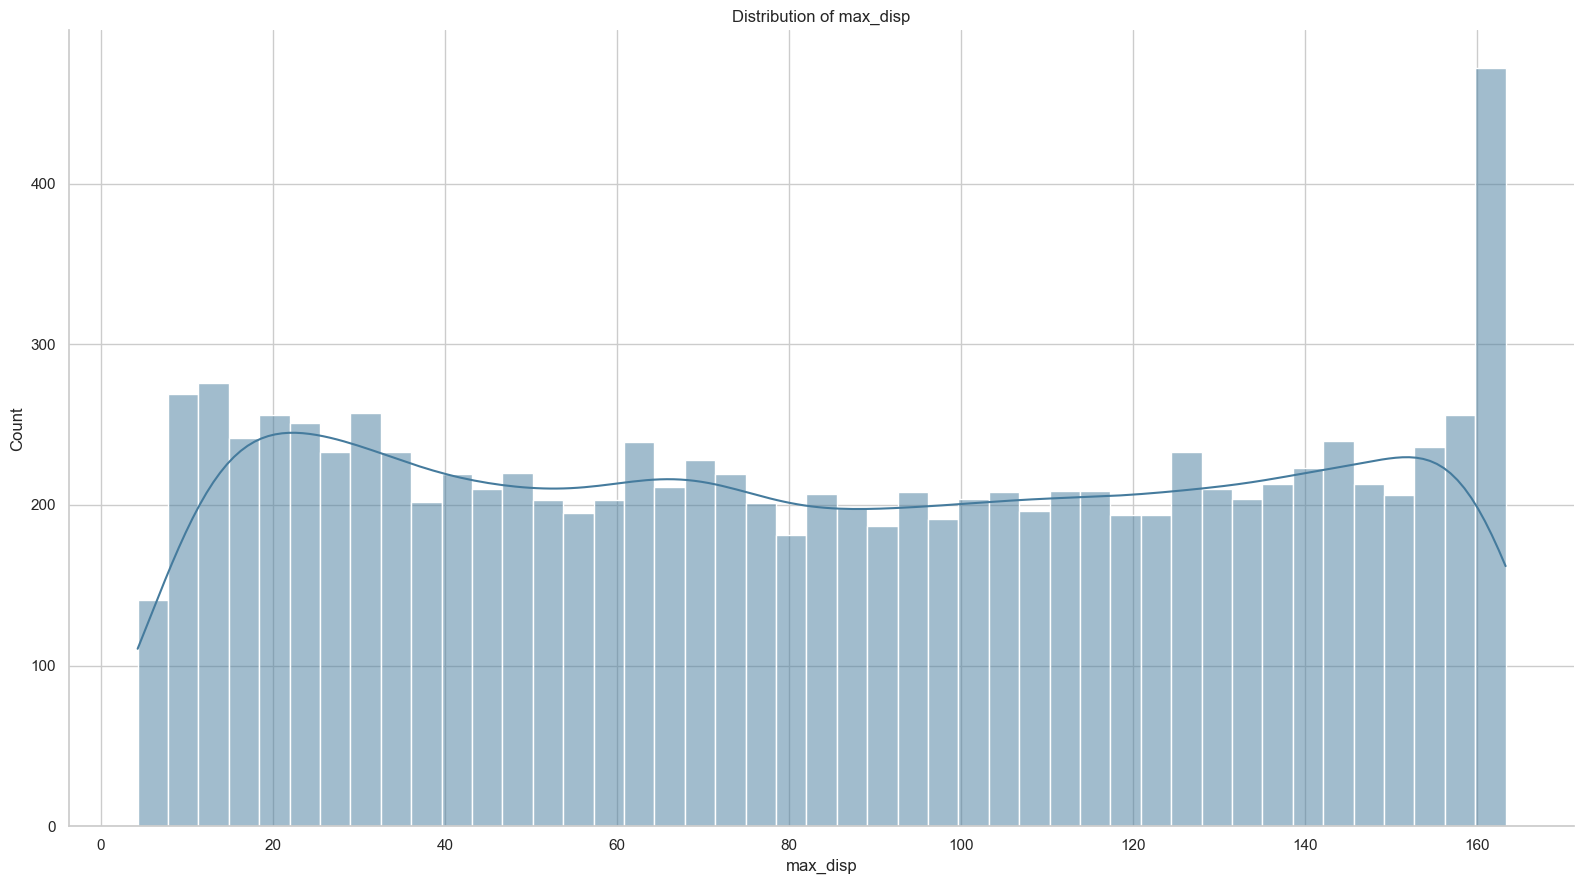

In [4]:
fig, ax = plt.subplots(figsize=(16, 9))

sns.histplot(y, bins=45, kde=True, color="#457b9d", ax=ax)
ax.set_title("Distribution of max_disp")
ax.set_xlabel("max_disp")
sns.despine(ax=ax)

corr_with_target = (
    df[feature_cols + ["max_disp"]]
    .corr(numeric_only=True)["max_disp"]
    .drop("max_disp")
    .sort_values(key=np.abs, ascending=False)
)

plt.tight_layout()
plt.show()


### PCA + t-SNE Projection (Structure in Feature Space)

Now you project the 28-dimensional feature space into 2 dimensions with two different methods. PCA is linear and tells you how much variance each principal axis captures. t-SNE is nonlinear and focuses on local neighborhoods, often revealing structure that PCA can miss. These methods are for understanding geometry, not for direct performance measurement.

For PCA, read the explained variance ratio as “how much of total feature variation this axis summarizes.” If PC1+PC2 is low, that does not mean PCA failed; it means the full dataset cannot be compressed cleanly into only 2 dimensions.

For t-SNE, avoid over-interpreting global distances. Axis values have no direct physical meaning. To keep runtime demo-friendly, we subsample before t-SNE.

References for deeper reading: [scikit-learn PCA User Guide](https://scikit-learn.org/stable/modules/decomposition.html#pca), [scikit-learn t-SNE User Guide](https://scikit-learn.org/stable/modules/manifold.html#t-sne), [Distill: How to Use t-SNE Effectively](https://distill.pub/2016/misread-tsne/).

PCA explained variance ratio -> PC1: 0.3387, PC2: 0.3317
PCA cumulative explained variance (PC1 + PC2): 0.6704


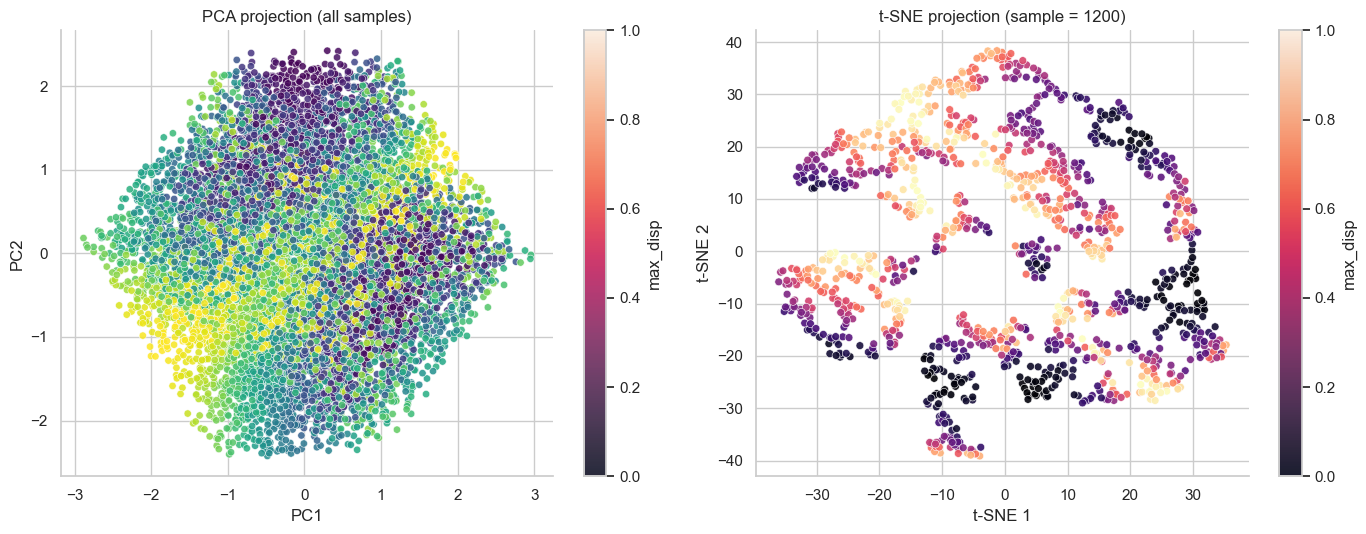

In [5]:
# Standardize only for visualization geometry; this is not the training scaler yet.
X_scaled_for_eda = StandardScaler().fit_transform(X)

# ----- PCA -----
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled_for_eda)

evr = pca.explained_variance_ratio_
print(f"PCA explained variance ratio -> PC1: {evr[0]:.4f}, PC2: {evr[1]:.4f}")
print(f"PCA cumulative explained variance (PC1 + PC2): {evr.sum():.4f}")

# ----- t-SNE (sampled for speed) -----
tsne_sample_size = min(1200, len(X_scaled_for_eda))
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(X_scaled_for_eda), size=tsne_sample_size, replace=False)
X_tsne_input = X_scaled_for_eda[sample_idx]
y_tsne = y.iloc[sample_idx].reset_index(drop=True)

X_tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=SEED,
).fit_transform(X_tsne_input)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

pca_plot_df = pd.DataFrame({"PC1": X_pca[:, 0], "PC2": X_pca[:, 1], "max_disp": y})
sns.scatterplot(
    data=pca_plot_df,
    x="PC1",
    y="PC2",
    hue="max_disp",
    palette="viridis",
    s=28,
    alpha=0.85,
    legend=False,
    ax=axes[0],
)
axes[0].set_title("PCA projection (all samples)")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
fig.colorbar(axes[0].collections[0], ax=axes[0], label="max_disp")

tsne_plot_df = pd.DataFrame({"t-SNE 1": X_tsne[:, 0], "t-SNE 2": X_tsne[:, 1], "max_disp": y_tsne})
sns.scatterplot(
    data=tsne_plot_df,
    x="t-SNE 1",
    y="t-SNE 2",
    hue="max_disp",
    palette="magma",
    s=32,
    alpha=0.9,
    legend=False,
    ax=axes[1],
)
axes[1].set_title(f"t-SNE projection (sample = {tsne_sample_size})")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")
fig.colorbar(axes[1].collections[0], ax=axes[1], label="max_disp")

sns.despine(fig=fig)
plt.tight_layout()
plt.show()


## 5. Train/Validation/Test Split

We split first, before fitting any preprocessing transforms, so the validation and test sets stay truly unseen. This is the foundation of honest evaluation. In this beginner regression workflow we do not stratify on a continuous target; instead we keep the random seed fixed so comparisons remain reproducible.

The two-step split below gives approximately 70% train, 15% validation, and 15% test. Validation is used during model development (for early stopping and model choices), while test is reserved for the final one-time performance estimate.

References for stronger foundations: [scikit-learn: train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html), [scikit-learn: StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html), [Data leakage overview (scikit-learn common pitfalls)](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage).

In [6]:
X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=SEED,
)

X_val_raw, X_test_raw, y_val, y_test = train_test_split(
    X_temp_raw,
    y_temp,
    test_size=0.50,
    random_state=SEED,
)

print("Split sizes:")
print(f"Train: {X_train_raw.shape[0]} samples")
print(f"Val:   {X_val_raw.shape[0]} samples")
print(f"Test:  {X_test_raw.shape[0]} samples")

print()
print("Target mean by split:")
print(f"Train mean max_disp: {y_train.mean():.3f}")
print(f"Val mean max_disp:   {y_val.mean():.3f}")
print(f"Test mean max_disp:  {y_test.mean():.3f}")


Split sizes:
Train: 7000 samples
Val:   1500 samples
Test:  1500 samples

Target mean by split:
Train mean max_disp: 84.923
Val mean max_disp:   86.700
Test mean max_disp:  82.529


## 6. Leakage-Safe Preprocessing (Standardization)

Neural networks train more reliably when feature scales are comparable. Standardization rescales each feature to zero mean and unit variance, but this transform must be fitted on training data only. If you fit the scaler on all data, information from validation/test leaks into training and inflates performance estimates.

Read the quick diagnostics at the end of this cell as a sanity check. You should see train-set scaled means close to 0 and standard deviations close to 1 for the reported features.

In [7]:
scaler = StandardScaler()

# Fit only on training inputs to avoid leakage.
X_train = scaler.fit_transform(X_train_raw)
X_val = scaler.transform(X_val_raw)
X_test = scaler.transform(X_test_raw)

print("Scaled arrays ready.")
print("Train scaled mean (first 5 features):", np.round(X_train.mean(axis=0)[:5], 3))
print("Train scaled std  (first 5 features):", np.round(X_train.std(axis=0)[:5], 3))


Scaled arrays ready.
Train scaled mean (first 5 features): [-0. -0. -0.]
Train scaled std  (first 5 features): [1. 1. 1.]


## 7. Baseline Model (LinearRegression)

A baseline answers one critical question: is the neural network actually adding value? Here we use **LinearRegression** as the main classical benchmark, because it tests whether a simple linear relationship already explains much of the signal in these 28 input features.

For this dataset, the linear baseline is the one that matters most. If the MLP cannot beat linear regression, then the extra nonlinear model capacity is not buying you much. If it does beat linear regression, that is evidence that nonlinear structure is helping.

Use the validation split here because we are still in development mode. Test data remains untouched until the final evaluation section.


In [8]:
linear_baseline = LinearRegression()
linear_baseline.fit(X_train, y_train)

linear_val_pred = linear_baseline.predict(X_val)

linear_val_mae = mean_absolute_error(y_val, linear_val_pred)
linear_val_rmse = root_mean_squared_error(y_val, linear_val_pred)
linear_val_r2 = r2_score(y_val, linear_val_pred)

print("Validation metrics - LinearRegression baseline")
print(f"MAE : {linear_val_mae:.4f}")
print(f"RMSE: {linear_val_rmse:.4f}")
print(f"R^2 : {linear_val_r2:.4f}")


Validation metrics - LinearRegression baseline
MAE : 38.3937
RMSE: 44.7262
R^2 : 0.1084


## 8. Neural Network Model (MLP)

Now we train a small multilayer perceptron for continuous prediction. For beginners, the aim is to understand the training loop and validation behavior, not to maximize benchmark numbers. Here we train with **Huber loss** and track **MAE**, **MSE**, and **RMSE** so you can compare different error views side by side.

High-level interpretation of the regression losses and metrics:

- **MAE (Mean Absolute Error)**: average absolute mistake size. It stays in the same units as `max_disp`, so it is easy to explain. Use it when you want a direct answer to "how far off are we on average?"
- **MSE (Mean Squared Error)**: average squared error. Large misses are penalized more heavily than small ones, so it is useful when big errors are especially costly.
- **RMSE (Root Mean Squared Error)**: square root of MSE. It still penalizes large mistakes strongly, but it returns to the original target units, which makes it easier to interpret than raw MSE.
- **Huber loss**: behaves like MSE for small errors and more like MAE for large errors. It is often a good default when you want stable training but do not want a few outliers to dominate the optimization.

In practice, a common pattern is:

- train with **MSE** when you want to punish large misses aggressively
- train with **MAE** when you care more about typical error size and want more robustness to outliers
- train with **Huber** when you want a compromise between those two behaviors
- report **MAE** and **RMSE** together at the end because they are both in the original units and describe different error sensitivities

Early stopping is enabled to prevent over-training once validation loss stops improving. This is a practical regularization pattern you will use often in real workflows.

References for model mechanics: [Keras Sequential API](https://keras.io/guides/sequential_model/), [Keras losses](https://keras.io/api/losses/regression_losses/), [Keras EarlyStopping](https://keras.io/api/callbacks/early_stopping/), [Adam optimizer paper](https://arxiv.org/abs/1412.6980).

In [9]:
model = keras.Sequential([
    keras.layers.Input(shape=(X_train.shape[1],)),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(1),
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.MeanSquaredError(),
    metrics=[
        keras.metrics.MeanAbsoluteError(name="mae"),
        keras.metrics.RootMeanSquaredError(name="rmse"),
    ],
)

early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=32,
    restore_best_weights=True,
)

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=4096,
    batch_size=128,
    callbacks=[early_stopping],
    verbose=1,
)

print(f"Training finished after {len(history.history['loss'])} epochs.")

Epoch 1/4096
55/55 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 9404.7432 - mae: 84.5055 - rmse: 96.9769 - val_loss: 9452.8379 - val_mae: 84.8895 - val_rmse: 97.2257
Epoch 2/4096
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 8984.0000 - mae: 81.9979 - rmse: 94.7822 - val_loss: 8600.0244 - val_mae: 79.8171 - val_rmse: 92.7363
Epoch 3/4096
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7935.1338 - mae: 75.6159 - rmse: 89.0712 - val_loss: 6761.8638 - val_mae: 68.7273 - val_rmse: 82.2306
Epoch 4/4096
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5916.3438 - mae: 63.2111 - rmse: 76.8874 - val_loss: 4223.4624 - val_mae: 52.6651 - val_rmse: 64.9882
Epoch 5/4096
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 3528.9207 - mae: 47.6558 - rmse: 59.3600 - val_loss: 2353.9219 - val_mae: 39.6037 - val_rmse: 48.5172
Epoch 6/4096
55/55 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2080.9255 - mae: 37.3658 - rmse: 45.6051 - val_loss: 1726.3910 - val_mae: 34.8523 - val_rmse: 41.5499
Epoch 7/4096
55/55 ━━━━━━━━━

## 9. Training Curves

Training curves help you diagnose model behavior beyond a single metric value. If training loss drops while validation loss rises, you are likely overfitting. If both losses stay high and flat, the model may be underfitting or learning too slowly.

Because this model trains with **Huber loss** and tracks **MAE**, **MSE**, and **RMSE**, we can inspect each view of the error during optimization. The loss curves show the objective the optimizer is minimizing, while the metric curves show prediction error in more interpretable forms. Focus on trend shape rather than one noisy epoch. The ideal pattern is a smooth reduction in both training and validation curves, followed by a plateau where early stopping ends training.


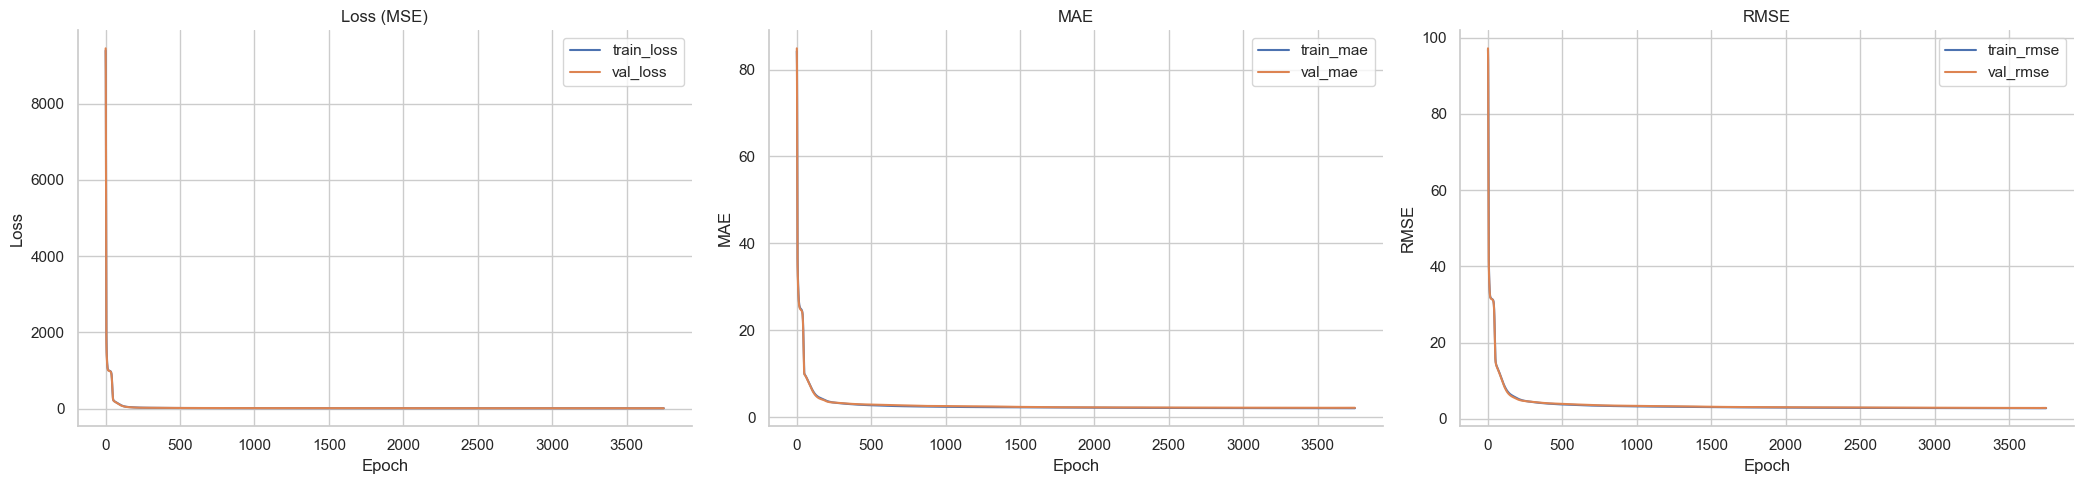

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(21, 5))
axes = axes.ravel()
history_df = pd.DataFrame(history.history)
history_df["epoch"] = np.arange(1, len(history_df) + 1)

sns.lineplot(data=history_df, x="epoch", y="loss", ax=axes[0], label="train_loss")
sns.lineplot(data=history_df, x="epoch", y="val_loss", ax=axes[0], label="val_loss")
axes[0].set_title("Loss (MSE)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

sns.lineplot(data=history_df, x="epoch", y="mae", ax=axes[1], label="train_mae")
sns.lineplot(data=history_df, x="epoch", y="val_mae", ax=axes[1], label="val_mae")
axes[1].set_title("MAE")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE")
axes[1].legend()

sns.lineplot(data=history_df, x="epoch", y="rmse", ax=axes[2], label="train_rmse")
sns.lineplot(data=history_df, x="epoch", y="val_rmse", ax=axes[2], label="val_rmse")
axes[2].set_title("RMSE")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("RMSE")
axes[2].legend()

sns.despine(fig=fig)
plt.tight_layout()
plt.show()


## 10. Final Evaluation on the Test Set

Only now do we touch the test set. This is your final, unbiased checkpoint after all modeling decisions are complete. We evaluate with multiple metrics because each one captures a different behavior:

- **MAE**: average absolute error in target units.
- **RMSE**: root-mean-square error, which penalizes larger misses more strongly than MAE.
- **R²**: explained variance relative to a mean-only predictor.

In this notebook you compare the MLP against a linear regression baseline. That is a strong sanity check for tabular data: if the MLP beats linear regression, then the extra nonlinear capacity is likely capturing structure that a simple linear model misses.

The prediction-vs-actual plot should cluster around the diagonal if the model is well calibrated. The residual plot should keep most points centered around zero, and its LOWESS trend should stay fairly flat rather than bending into a strong curve. The residual histogram should also be centered near zero; strong skew or very heavy tails suggest systematic bias or unresolved nonlinear structure.


Test metrics - MLP
MAE : 2.1563
RMSE: 2.9242
R^2 : 0.9964

Test metrics - LinearRegression baseline
MAE : 39.8341
RMSE: 46.1054
R^2 : 0.1044


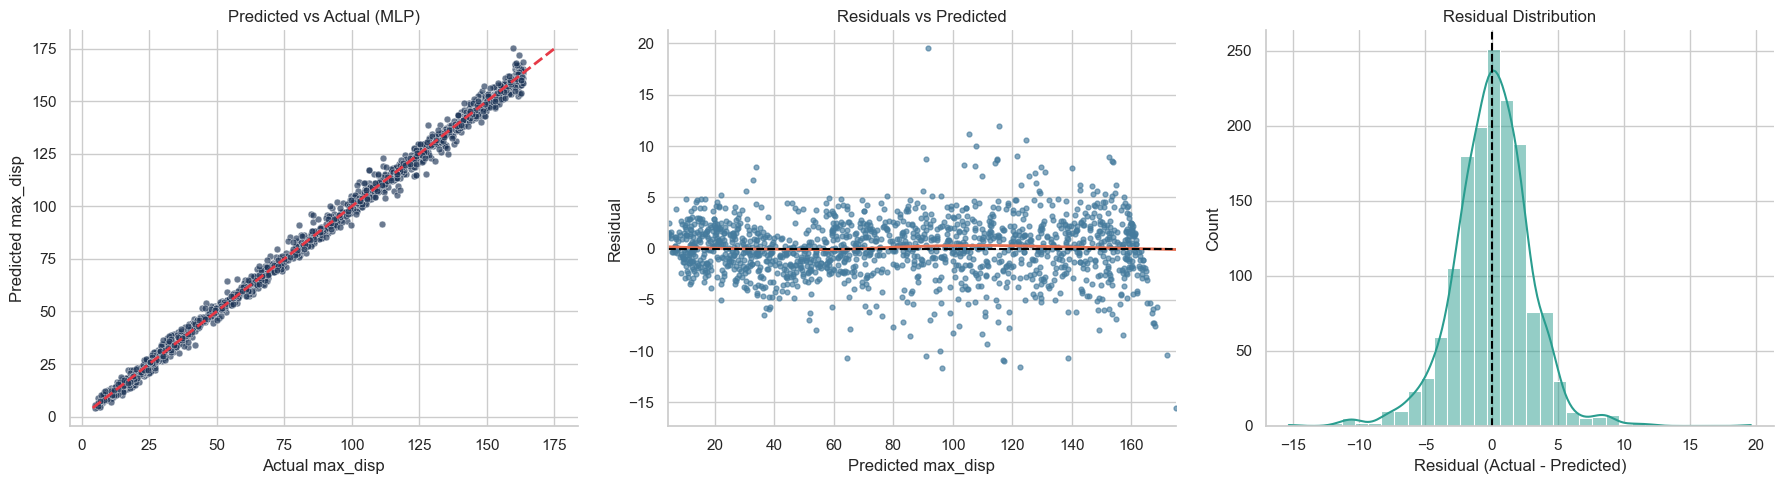

In [11]:
# MLP predictions
mlp_test_pred = model.predict(X_test, verbose=0).ravel()

# Baseline predictions
linear_test_pred = linear_baseline.predict(X_test)

# Metrics for MLP
mlp_mae = mean_absolute_error(y_test, mlp_test_pred)
mlp_rmse = root_mean_squared_error(y_test, mlp_test_pred)
mlp_r2 = r2_score(y_test, mlp_test_pred)

# Metrics for LinearRegression
linear_mae = mean_absolute_error(y_test, linear_test_pred)
linear_rmse = root_mean_squared_error(y_test, linear_test_pred)
linear_r2 = r2_score(y_test, linear_test_pred)

print("Test metrics - MLP")
print(f"MAE : {mlp_mae:.4f}")
print(f"RMSE: {mlp_rmse:.4f}")
print(f"R^2 : {mlp_r2:.4f}")

print()
print("Test metrics - LinearRegression baseline")
print(f"MAE : {linear_mae:.4f}")
print(f"RMSE: {linear_rmse:.4f}")
print(f"R^2 : {linear_r2:.4f}")

y_test_vals = np.asarray(y_test).reshape(-1)
pred_vals = np.asarray(mlp_test_pred).reshape(-1)
residuals = y_test_vals - pred_vals

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(x=y_test_vals, y=pred_vals, alpha=0.65, s=24, color="#1d3557", ax=axes[0])
min_v = min(y_test_vals.min(), pred_vals.min())
max_v = max(y_test_vals.max(), pred_vals.max())
sns.lineplot(x=[min_v, max_v], y=[min_v, max_v], ax=axes[0], color="#e63946", linestyle="--", linewidth=2)
axes[0].set_title("Predicted vs Actual (MLP)")
axes[0].set_xlabel("Actual max_disp")
axes[0].set_ylabel("Predicted max_disp")

sns.residplot(
    x=pred_vals,
    y=y_test_vals,
    lowess=True,
    ax=axes[1],
    scatter_kws={"alpha": 0.65, "s": 12, "color": "#457b9d"},
    line_kws={"color": "#e76f51", "linewidth": 2},
)
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set_title("Residuals vs Predicted")
axes[1].set_xlabel("Predicted max_disp")
axes[1].set_ylabel("Residual")

sns.histplot(residuals, bins=35, kde=True, color="#2a9d8f", ax=axes[2])
axes[2].axvline(0, color="black", linestyle="--")
axes[2].set_title("Residual Distribution")
axes[2].set_xlabel("Residual (Actual - Predicted)")

sns.despine(fig=fig)
plt.tight_layout()
plt.show()


## 11. Save Trained Artifacts

Save both the regressor and the preprocessing objects needed for inference. Because the model expects standardized tabular inputs, the fitted scaler must travel with the `.keras` file.

In [13]:
if Path("inclass_examples").exists():
    artifacts_dir = Path("inclass_examples/artifacts/mlp_regression")
else:
    artifacts_dir = Path("../artifacts/mlp_regression")

artifacts_dir.mkdir(parents=True, exist_ok=True)

import json
import pickle

model_path = artifacts_dir / "maxDisplacement_regressor.keras"
scaler_path = artifacts_dir / "maxDisplacement_regressor_scaler.pkl"
metadata_path = artifacts_dir / "maxDisplacement_regressor_metadata.json"

model.save(model_path)

with scaler_path.open("wb") as f:
    pickle.dump(scaler, f)

metadata = {
    "source_csv": str(CSV_PATH),
    "target_col": "max_disp",
    "feature_cols": feature_cols,
    "seed": SEED,
    "test_metrics": {
        "mlp_mae": float(mlp_mae),
        "mlp_rmse": float(mlp_rmse),
        "mlp_r2": float(mlp_r2),
        "linear_mae": float(linear_mae),
        "linear_rmse": float(linear_rmse),
        "linear_r2": float(linear_r2),
    },
}
metadata_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

print(f"Saved model to: {model_path.resolve()}")
print(f"Saved scaler to: {scaler_path.resolve()}")
print(f"Saved metadata to: {metadata_path.resolve()}")


Saved model to: C:\Users\Ozguc\Documents\GitHub\CMDO-ML\inclass_examples\artifacts\mlp_regression\maxDisplacement_regressor.keras
Saved scaler to: C:\Users\Ozguc\Documents\GitHub\CMDO-ML\inclass_examples\artifacts\mlp_regression\maxDisplacement_regressor_scaler.pkl
Saved metadata to: C:\Users\Ozguc\Documents\GitHub\CMDO-ML\inclass_examples\artifacts\mlp_regression\maxDisplacement_regressor_metadata.json


## 12. Mini Exercises

1. Replace `LinearRegression` with `Ridge` and compare it against `LinearRegression` and the MLP on the test set.
2. Change hidden-layer sizes (for example, `128 -> 64`) and evaluate whether MAE and RMSE improve consistently or only on validation.
3. Experiment with `patience` in early stopping (`10`, `20`, `30`) and explain how training duration and test quality change.
4. Try a log transform on the target (`np.log1p(max_disp)`) and compare residual shape before and after inverse-transforming predictions.
